In [ ]:
!pip uninstall ssm

!pip install git+https://github.com/lindermanlab/ssm.git

In [3]:
import numpy as np
import pandas as pd
import random

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, confusion_matrix

import matplotlib.pyplot as plt

import ssm

ModuleNotFoundError: No module named 'autograd.scipy.misc'

# Generating $N$ 1-2-1 Trials

In [2]:
def generate_trials(num_trials, screen_width = 12):
    trials_list = []

    for i in range(num_trials):
        entry_hole = random.randint(1, screen_width-1)
        left_hole = random.randint(0, entry_hole-1)
        right_hole = random.randint(entry_hole+1, screen_width)
        exit_hole = random.randint(left_hole, right_hole)
        
        trials_list.append({
            'Entry': entry_hole,
            'Left Hole': left_hole,
            'Right Hole': right_hole,
            'Exit': exit_hole
        })

    return pd.DataFrame(trials_list)

In [3]:
def generate_sample_decisions(trials, strategy_function, probability = 0.1):

    input_variables = pd.DataFrame({
        'L1': np.abs(trials['Entry']-trials['Left Hole']),
        'L2': np.abs(trials['Exit']-trials['Left Hole']),
        'R1': np.abs(trials['Entry']-trials['Right Hole']),
        'R2': np.abs(trials['Exit']-trials['Right Hole']),
        'Direction': np.sign(trials['Exit'].shift(1)-trials['Entry']).fillna(0)
    })

    decisions = strategy_function(input_variables, probability)

    return decisions

In [4]:
def deterministic_greedy_selection(invar, probability):
    return invar['L1'] < invar['R1']

def deterministic_planning_selection(invar, probability):
    return (invar['L1']+invar['L2']) < (invar['R1']+invar['R2'])

def stochastic_greedy_selection(invar, probability):
    output = invar['L1'] < invar['R1']
    for i in range(len(output)):
        p = random.random()
        if p < probability:
            output[i] = ~output[i]
    return output

def stochastic_planning_selection(invar, probability):
    output = (invar['L1']+invar['L2']) < (invar['R1']+invar['R2'])
    for i in range(len(output)):
        p = random.random()
        if p < probability:
            output[i] = ~output[i]
    return output


In [5]:
def plot_coeffecients_over_trials(trials, decisions):
    accuracy_over_trials = []
    coeffecients_over_trials = []
    loss_over_trials = []

    for i in range(int(len(trials)/100)-1):
        trials = trials[0: 100*(i+1)]
        decisions = decisions[0: 100*(i+1)]
        input_variables = pd.DataFrame({
                'L1': np.abs(trials['Entry']-trials['Left Hole']),
                'L2': np.abs(trials['Exit']-trials['Left Hole']),
                'R1': np.abs(trials['Entry']-trials['Right Hole']),
                'R2': np.abs(trials['Exit']-trials['Right Hole']),
                'Direction': np.sign(trials['Exit'].shift(1)-trials['Entry']).fillna(0)
            })

        X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(input_variables, decisions, test_size = 0.2)

        model = sklearn.linear_model.LogisticRegression().fit(X_train, y_train)

        accuracy = model.score(X_test, y_test)
        #print(f'Accuracy:', accuracy,'\n')

        accuracy_over_trials.append(accuracy)
        coeffecients_over_trials.append(pd.Series(model.coef_[0], index = X_train.columns))

        y_probs = model.predict_proba(X_test)
        loss_over_trials.append(log_loss(y_test, y_probs))

        #print(f'Coeffecients:\n', pd.Series(model.coef_[0], index=X_train.columns),'\n')
    coeffecients_over_trials = pd.DataFrame(coeffecients_over_trials)
    coeffecients_over_trials

    plt.plot([i * 100 for i in range(len(coeffecients_over_trials))], coeffecients_over_trials['L1'], label = 'L1')
    plt.plot([i * 100 for i in range(len(coeffecients_over_trials))], coeffecients_over_trials['R1'], label = 'R1')
    plt.plot([i * 100 for i in range(len(coeffecients_over_trials))], coeffecients_over_trials['L2'], label = 'L2')
    plt.plot([i * 100 for i in range(len(coeffecients_over_trials))], coeffecients_over_trials['R2'], label = 'R2')
    plt.legend()
    plt.xlabel('Number of Trials')
    plt.ylabel('Values of the Coeffecients')
    plt.show()

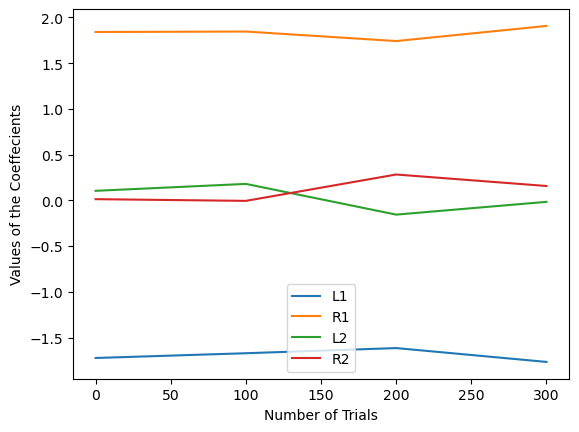

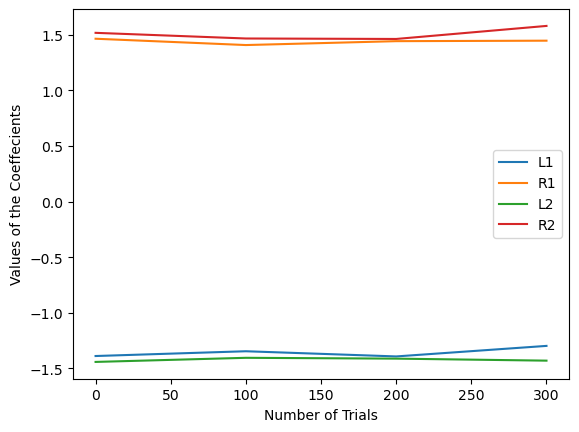

In [6]:
trials = generate_trials(500)
#trials
decisions_greedy_deterministic = generate_sample_decisions(trials, deterministic_greedy_selection)
plot_coeffecients_over_trials(trials, decisions_greedy_deterministic)
decisions_planning_deterministic = generate_sample_decisions(trials, deterministic_planning_selection)
plot_coeffecients_over_trials(trials, decisions_planning_deterministic)

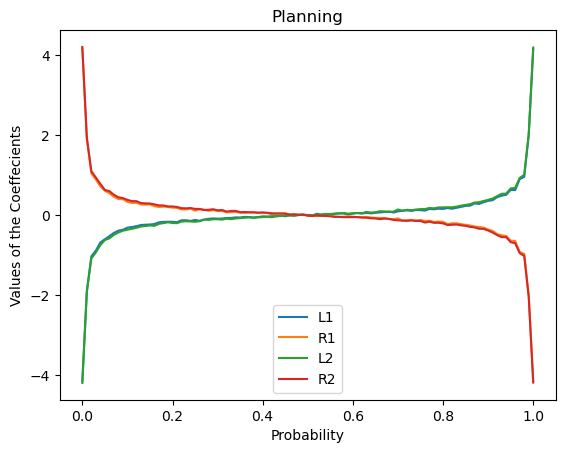

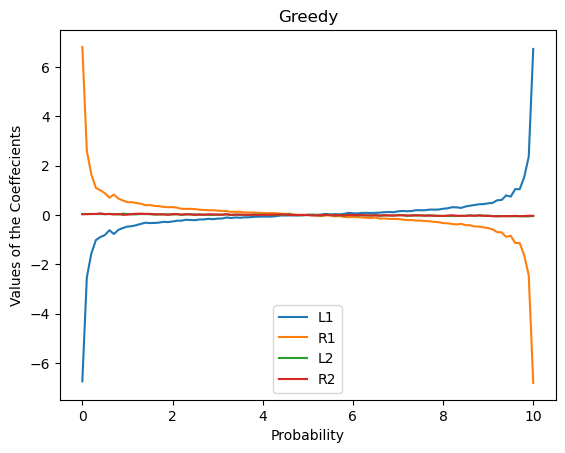

In [7]:
trials = generate_trials(5000)

accuracy_over_probs_g = []
coeffecients_over_probs_g = []
loss_over_probs_g = []
accuracy_over_probs_p = []
coeffecients_over_probs_p = []
loss_over_probs_p = []

input_variables = pd.DataFrame({
                'L1': np.abs(trials['Entry']-trials['Left Hole']),
                'L2': np.abs(trials['Exit']-trials['Left Hole']),
                'R1': np.abs(trials['Entry']-trials['Right Hole']),
                'R2': np.abs(trials['Exit']-trials['Right Hole']),
                'Direction': np.sign(trials['Exit'].shift(1)-trials['Entry']).fillna(0)
            })

granularity = 101

for i in range(granularity):

    decisions_greedy = stochastic_greedy_selection(input_variables, probability= i/(granularity-1))
    decisions_planning = stochastic_planning_selection(input_variables, probability = i/(granularity-1))

    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(input_variables, decisions_greedy, test_size = 0.2)

    model = sklearn.linear_model.LogisticRegression().fit(X_train, y_train)

    accuracy = model.score(X_test, y_test)
    accuracy_over_probs_g.append(accuracy)
    coeffecients_over_probs_g.append(pd.Series(model.coef_[0], index = X_train.columns))

    y_probs = model.predict_proba(X_test)
    loss_over_probs_p.append(log_loss(y_test, y_probs))

    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(input_variables, decisions_planning, test_size = 0.2)

    model = sklearn.linear_model.LogisticRegression().fit(X_train, y_train)

    accuracy = model.score(X_test, y_test)
    accuracy_over_probs_p.append(accuracy)
    coeffecients_over_probs_p.append(pd.Series(model.coef_[0], index = X_train.columns))

    y_probs = model.predict_proba(X_test)
    loss_over_probs_p.append(log_loss(y_test, y_probs))

coeffecients_over_probs_p = pd.DataFrame(coeffecients_over_probs_p)
coeffecients_over_probs_g = pd.DataFrame(coeffecients_over_probs_g)

plt.plot([i/(granularity-1) for i in range(len(coeffecients_over_probs_p))], coeffecients_over_probs_p['L1'], label = 'L1')
plt.plot([i/(granularity-1) for i in range(len(coeffecients_over_probs_p))], coeffecients_over_probs_p['R1'], label = 'R1')
plt.plot([i/(granularity-1) for i in range(len(coeffecients_over_probs_p))], coeffecients_over_probs_p['L2'], label = 'L2')
plt.plot([i/(granularity-1) for i in range(len(coeffecients_over_probs_p))], coeffecients_over_probs_p['R2'], label = 'R2')
plt.legend()
plt.xlabel('Probability')
plt.ylabel('Values of the Coeffecients')
plt.title('Planning')
plt.show()

plt.plot([i * 0.1 for i in range(len(coeffecients_over_probs_g))], coeffecients_over_probs_g['L1'], label = 'L1')
plt.plot([i * 0.1 for i in range(len(coeffecients_over_probs_g))], coeffecients_over_probs_g['R1'], label = 'R1')
plt.plot([i * 0.1 for i in range(len(coeffecients_over_probs_g))], coeffecients_over_probs_g['L2'], label = 'L2')
plt.plot([i * 0.1 for i in range(len(coeffecients_over_probs_g))], coeffecients_over_probs_g['R2'], label = 'R2')
plt.legend()
plt.xlabel('Probability')
plt.ylabel('Values of the Coeffecients')
plt.title('Greedy')
plt.show()

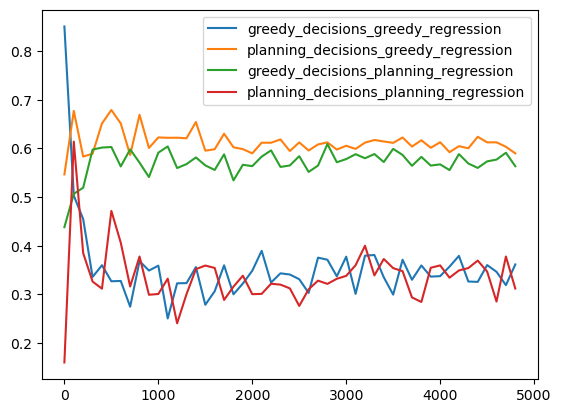

In [ ]:
trials = generate_trials(5000)

input_variables = pd.DataFrame({
                'L1': np.abs(trials['Entry']-trials['Left Hole']),
                'L2': np.abs(trials['Exit']-trials['Left Hole']),
                'R1': np.abs(trials['Entry']-trials['Right Hole']),
                'R2': np.abs(trials['Exit']-trials['Right Hole']),
                'Direction': np.sign(trials['Exit'].shift(1)-trials['Entry']).fillna(0)
            })


input_variables_2 = pd.DataFrame({
    "greedy_diff": input_variables['L1'] - input_variables['R1'],
    "planning_diff": (input_variables['L1'] + input_variables['L2']) - (input_variables['R1'] + input_variables['R2']),
    "direction": input_variables['Direction']
})

decisions_greedy = stochastic_greedy_selection(input_variables, probability = 0.05)
decisions_planning = stochastic_planning_selection(input_variables, probability = 0.05)

def return_loss_plot(input_vector, decisions_vector):
    loss_plot = []

    for i in range(int(len(trials)/100)-1):
        input_in_loop = input_vector[0:(i+1)*100]
        decisions_in_loop = decisions_vector[0:(i+1)*100]

        X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(input_in_loop, 
                                                    decisions_in_loop, test_size = 0.2)
        model = sklearn.linear_model.LogisticRegression().fit(X_train, y_train)

        y_probs = model.predict_proba(X_test)
        loss_plot.append(log_loss(y_test, y_probs))

    return loss_plot

greedy_decisions_greedy_regression = return_loss_plot(input_variables_2[['greedy_diff']], decisions_greedy)
planning_decisions_greedy_regression = return_loss_plot(input_variables_2[['greedy_diff']], decisions_planning)
greedy_decisions_planning_regression = return_loss_plot(input_variables_2[['planning_diff']], decisions_greedy)
planning_decisions_planning_regression = return_loss_plot(input_variables_2[['planning_diff']], decisions_planning)

plt.plot([i * 100 for i in range(len(greedy_decisions_greedy_regression))], greedy_decisions_greedy_regression,
         label = 'greedy_decisions_greedy_regression')
plt.plot([i * 100 for i in range(len(greedy_decisions_greedy_regression))], planning_decisions_greedy_regression,
         label = 'planning_decisions_greedy_regression')
plt.plot([i * 100 for i in range(len(greedy_decisions_greedy_regression))], greedy_decisions_planning_regression,
         label = 'greedy_decisions_planning_regression')
plt.plot([i * 100 for i in range(len(greedy_decisions_greedy_regression))], planning_decisions_planning_regression,
         label = 'planning_decisions_planning_regression')
plt.legend()


  Using cached ssm-0.0.1.tar.gz (309 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Obtaining dependency information for autograd from https://files.pythonhosted.org/packages/84/ea/e16f0c423f7d83cf8b79cae9452040fb7b2e020c7439a167ee7c317de448/autograd-1.8.0-py3-none-any.whl.metadata
  Using cached autograd-1.8.0-py3-none-any.whl.metadata (7.5 kB)
Using cached autograd-1.8.0-py3-none-any.whl (51 kB)
  Created wheel for ssm: filename=ssm-0.0.1-cp311-cp311-win_amd64.whl size=220309 sha256=084c761045479969e726bd65413d6c69143d83079be5025d039bba2a693f160c
  Stored in directory: c:\users\manik\appdata\local\pip\cache\wheels\3b\47\1e\47fe4eb9d5d5d3f828c6541dd0c60dd64b7a388cd4176abe32
Successfully built ssm
